<h1> Data Science Project: Planning Stage (Individual) </h>

In [26]:
library(tidyverse)
library(repr)
options(repr.matrix.max.rows = 6)
library(patchwork)
source("cleanup.R")

Warning message in file(filename, "r", encoding = encoding):
“cannot open file 'cleanup.R': No such file or directory”


ERROR: Error in file(filename, "r", encoding = encoding): cannot open the connection


<h2> Data Description </h2>

In [24]:
player_data = read_csv('https://raw.githubusercontent.com/noahfunguy5080-sudo/Individual-project/refs/heads/main/data/players.csv')
sessions_data = read_csv('https://raw.githubusercontent.com/noahfunguy5080-sudo/Individual-project/refs/heads/main/data/sessions.csv')
player_data
sessions_data

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
⋮,⋮,⋮,⋮,⋮
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,28/07/2024 15:36,28/07/2024 15:57,1.72218e+12,1.72218e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,25/07/2024 06:15,25/07/2024 06:22,1.72189e+12,1.72189e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,20/05/2024 02:26,20/05/2024 02:45,1.71617e+12,1.71617e+12


<h2> Number of Observations </h2>

In [25]:
observations_for_player_data = nrow(player_data)
observations_for_sessions_data = nrow(sessions_data)

observations_for_player_data
observations_for_sessions_data

[1] 196

[1] 1535

<h2> Number of Variables </h2>

In [26]:
variables_for_player_data = ncol(player_data)
vairables_for_sessions_data = ncol(sessions_data)
variables_for_player_data
vairables_for_sessions_data

[1] 7

[1] 5

<h2> Summary Statistics </h2>

<h2> Session Data </h2>

In [27]:
time_difference = sessions_data |>
    mutate(original_time_difference = original_end_time - original_start_time)
  
max_min_avrg_sec_time_difference = time_difference |>
    summarize(max_time = max(original_time_difference / 1000, na.rm = TRUE),
             average_time = mean(original_time_difference / 1000, na.rm = TRUE),
             min_time = min(original_time_difference / 1000, na.rm = TRUE)) |>
    round(digit = 2)

max_min_avrg_min_time_difference = mutate(max_min_avrg_sec_time_difference, 
                                          max_min_time = max_time / 60,
                                          average_min_time = average_time / 60,
                                          min_min_time = min_time / 60) |>
    select(max_min_time, average_min_time, min_min_time) |>
    round(digit = 2)

max_min_avrg_hour_time_difference = mutate(max_min_avrg_min_time_difference, 
                                          max_hour_time = max_min_time / 60,
                                          average_hour_time = average_min_time / 60,
                                          min_hour_time = min_min_time / 60) |>
    select(max_hour_time, average_hour_time, min_hour_time) |>
    round(digit = 2)

max_min_avrg_day_time_difference = mutate(max_min_avrg_hour_time_difference, 
                                          max_day_time = max_hour_time / 24,
                                          average_day_time = average_hour_time / 24,
                                          min_day_time = min_hour_time / 24) |>
    select(max_day_time, average_day_time, min_day_time) |>
    round(digit = 2)

max_min_avrg_sec_time_difference
max_min_avrg_min_time_difference
max_min_avrg_hour_time_difference
max_min_avrg_day_time_difference

max_time,average_time,min_time
<dbl>,<dbl>,<dbl>
20000,2909.33,0


max_min_time,average_min_time,min_min_time
<dbl>,<dbl>,<dbl>
333.33,48.49,0


max_hour_time,average_hour_time,min_hour_time
<dbl>,<dbl>,<dbl>
5.56,0.81,0


max_day_time,average_day_time,min_day_time
<dbl>,<dbl>,<dbl>
0.23,0.03,0


<h2> Player Data </h2>

In [28]:
player_data

max_min_avrg_hours = player_data |>
    summarize(max_hours = max(played_hours, na.rm = TRUE),
             average_hours = mean(played_hours, na.rm = TRUE),
             min_hours = min(played_hours, na.rm = TRUE)) |>
    round(digits = 2)

max_min_avrg_age = player_data |>
    summarize(max_age = max(Age, na.rm = TRUE),
             average_age = mean(Age, na.rm = TRUE),
             min_age = min(Age, na.rm = TRUE)) |>
    round(digits = 2)

experiences_max_min_avrg_hours = player_data |>
    group_by(experience) |>
    summarize(max_hours = max(played_hours, na.rm = TRUE),
             average_hours = mean(played_hours, na.rm = TRUE),
             min_hours = min(played_hours, na.rm = TRUE)) |>
    mutate(max_hours = round(max_hours, digits = 2),
          average_hours = round(average_hours, digits = 2),
          min_hours = round(min_hours, digits = 2))

experiences_max_min_avrg_age = player_data |>
    group_by(experience) |>
    summarize(max_age = max(Age, na.rm = TRUE),
             average_age = mean(Age, na.rm = TRUE),
             min_age = min(Age, na.rm = TRUE)) |>
    mutate(max_age = round(max_age, digits = 2),
          average_age = round(average_age, digits = 2),
          min_age = round(min_age, digits = 2))

subscriber_max_min_avrg_hours = player_data |>
    group_by(subscribe) |>
    summarize(max_hours = max(played_hours, na.rm = TRUE),
             average_hours = mean(played_hours, na.rm = TRUE),
             min_hours = min(played_hours, na.rm = TRUE)) |>
    mutate(max_hours = round(max_hours, digits = 2),
          average_hours = round(average_hours, digits = 2),
          min_hours = round(min_hours, digits = 2))


number_of_subscribers = player_data |>
    group_by(experience) |>
    summarize(yes_subscribed = sum(subscribe, na.rm = TRUE),
             no_subscribed = sum(!subscribe, na.rm = TRUE))


max_min_avrg_hours
max_min_avrg_age
experiences_max_min_avrg_hours
experiences_max_min_avrg_age
subscriber_max_min_avrg_hours
number_of_subscribers

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


max_hours,average_hours,min_hours
<dbl>,<dbl>,<dbl>
223.1,5.85,0


max_age,average_age,min_age
<dbl>,<dbl>,<dbl>
58,21.14,9


experience,max_hours,average_hours,min_hours
<chr>,<dbl>,<dbl>,<dbl>
Amateur,150.0,6.02,0
Beginner,23.7,1.25,0
Pro,30.3,2.60,0
Regular,223.1,18.21,0
Veteran,12.5,0.65,0


experience,max_age,average_age,min_age
<chr>,<dbl>,<dbl>,<dbl>
Amateur,57,21.37,11
Beginner,42,21.66,17
Pro,25,16.92,9
Regular,58,22.03,10
Veteran,46,20.96,16


subscribe,max_hours,average_hours,min_hours
<lgl>,<dbl>,<dbl>,<dbl>
FALSE,7.1,0.50,0
TRUE,223.1,7.78,0


experience,yes_subscribed,no_subscribed
<chr>,<int>,<int>
Amateur,45,18
Beginner,27,8
Pro,10,4
Regular,29,7
Veteran,33,15


<h2> Summary Table </h2>

<h2> Sessions data </h2>

<center> <h3> Table 1 - Number of observations/variables </h3> <center>

| Number of Observations  | Number of Variables |
| -------- | ------- | 
| 1535 | 5  |

<h3> Table 2 - Variables </h3>

| Name | Type | Description |
| --- | --- | --- |
| hasedEmail | chr | player email that has been de-identified |
| start_time | chr | start time with date and time |
| end_time | chr | end time with date and time |
| original_start_time | dbl | start time in UNIX time (milliseconds) |
| original_end_time | dbl | end time in UNIX time (milliseconds) |

<h3> Table 3 - Amount of time played </h3>

| Time Played | Seconds | Minutes | Hours | Days |
| -------------- | ---  | --- | --- | --- |
| max | 20000 | 333.33 | 5.56 | 0.23 |
| average | 2909.33 | 48.49 | 0.81 | 0.03 |
| min | 0 | 0 | 0 | 0 |



<h2> Player data </h2>

<center> <h3> Table 1 - Number of observations/variables </h3> <center> 

| Number of Observations  | Number of Variables |
| -------- | ------- | 
| 196 | 7  |

<h3> Table 2 - Variables </h3> 

| Name | Type | Description |
| --- | --- | --- |
| Experience | chr | player skill level |
| subscribe | lgl | subscribed to a game-related newsletter or not |
| hasedEmail | chr | player email that has been de-identified |
|played_hours| dbl | hours played in game |
| name | chr | name of participant |
| gender | chr | gender of participant |
|Age| dbl | age of participant |


<h3> Table 3 - Amount of hours played</h3>

| Statistics | Hours played |
| --- | --- |
| max | 223.1 |
| average | 5.85 |	 
| min | 0 |

<h3> Table 4 - Age of participants </h3>

| Statistics | Age |
| --- | --- |
| max | 58 |
| average | 21.14 |
| min | 9 |

<h3> Table 5 - Hours played for each experienced group </h3>

|Experience | Max | Average | Min |
| --- | --- | --- |--- |
| Beginner| 23.7 | 1.25 | 0 |
| Amateur| 150.0 | 	6.02 | 0 |
| Regular | 223.1 | 18.21 | 0 |
| Veteran | 12.5 |	0.65 | 0 |
| Pro | 30.3 | 2.60 | 0 |

<h3> Table 6 - Age of each experienced group </h3>

|Experience | Max | Average | Min |
| --- | --- | --- |--- |
| Beginner| 42 | 21.66 | 17 | 
| Amateur| 57 | 	21.37 | 11 |
| Regular | 58 | 22.03 | 10 |
| Veteran | 46 |	20.96 |16 |
| Pro | 25 | 16.92 | 9 |

<h3> Table 7 - Age of subscribed vs non-subscribed groups </h3>

| Subscription | Max | Average | Min |
| --- | --- | --- |--- |
| Yes| 7.1 | 0.50 | 0 |
| No| 223.1 | 	7.78 | 0 |

<h3> Table 8 - Experience of subscribed vs non-subscribed groups </h3>

|Experience | Subscribed | Not Subscribed |
| --- | --- | --- |
| Beginner| 45 | 8 |
| Amateur| 27 | 18 |
| Regular | 10 | 7 |
| Veteran | 29 | 15 |
| Pro | 33 | 4 |


<h3> Data collection </h3>
Data was collected through a continous video stream of people playing Minecraft which tracks the amount of time they played. One issue with the collection is the experience level could be arbitrary if it people self assigned it.

<h1> Exporatory Data Analysis and Visualization </h1>

In [29]:
tidy_time = sessions_data |>
    separate(col = start_time,
             into = c('start_date', 'start_time'),
             sep = ' ') |>
    separate(col = end_time,
             into = c('end_date', 'end_time'),
             sep = ' ') 

tidy_player = player_data |>
    mutate(experience = as_factor(experience),
           gender = as_factor(gender), 
          Age = as.integer(Age))

tidy_time
tidy_player

hashedEmail,start_date,start_time,end_date,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024,18:12,30/06/2024,18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024,23:33,17/06/2024,23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024,17:34,25/07/2024,17:57,1.72193e+12,1.72193e+12
⋮,⋮,⋮,⋮,⋮,⋮,⋮
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,28/07/2024,15:36,28/07/2024,15:57,1.72218e+12,1.72218e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,25/07/2024,06:15,25/07/2024,06:22,1.72189e+12,1.72189e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,20/05/2024,02:26,20/05/2024,02:45,1.71617e+12,1.71617e+12


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<fct>,<lgl>,<chr>,<dbl>,<chr>,<fct>,<int>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


<h2> Visualization </h2>

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


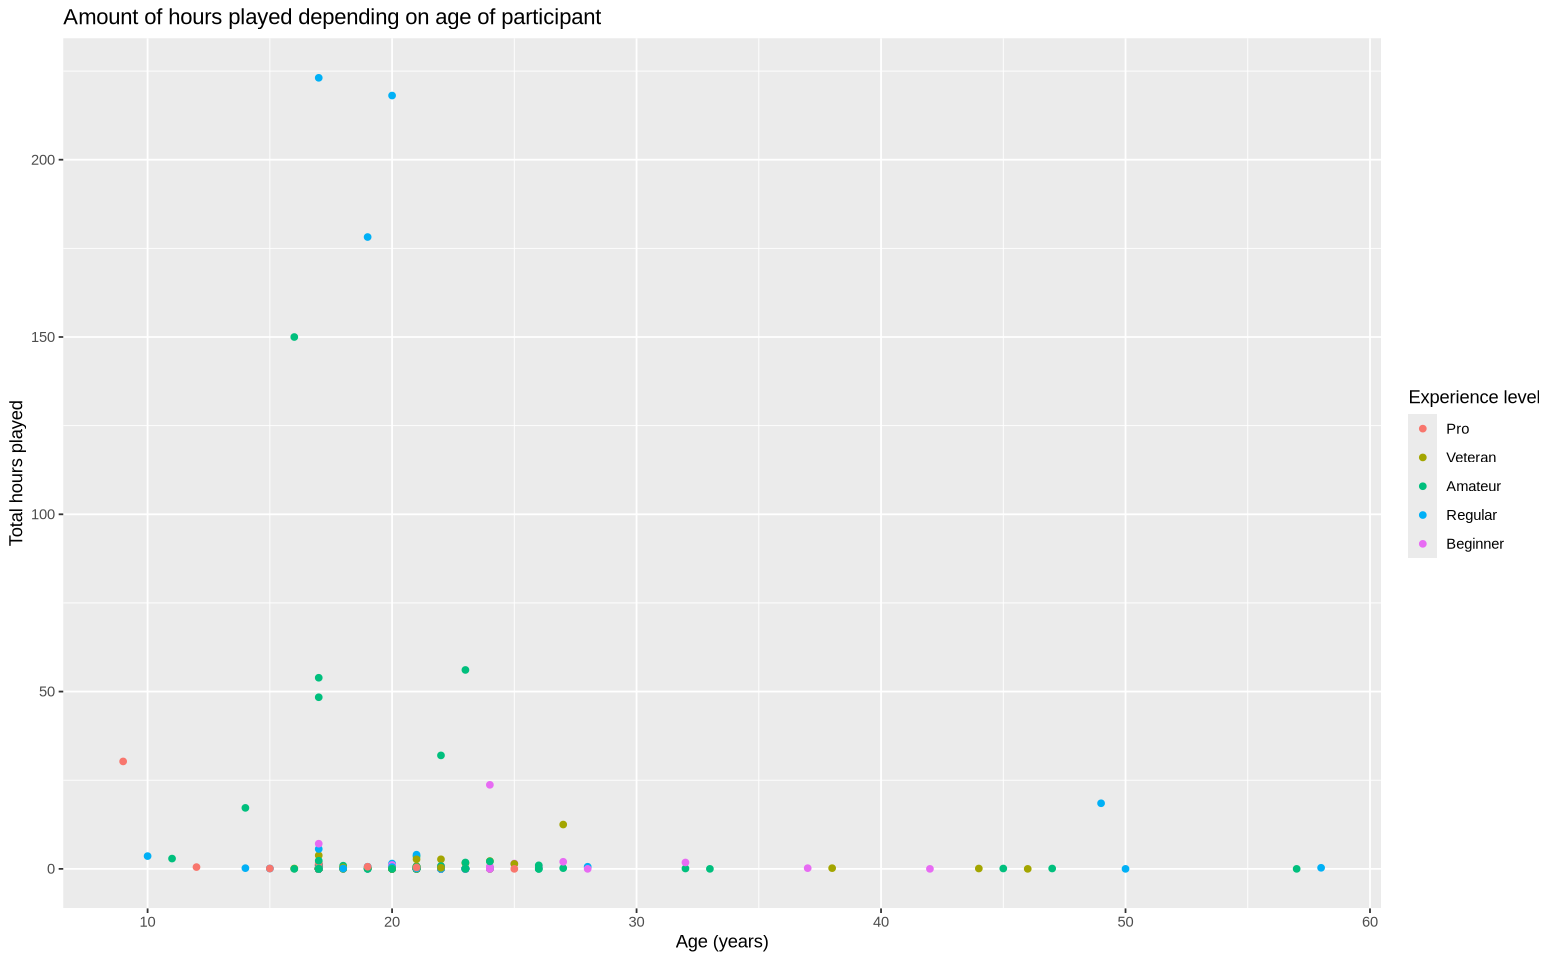

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


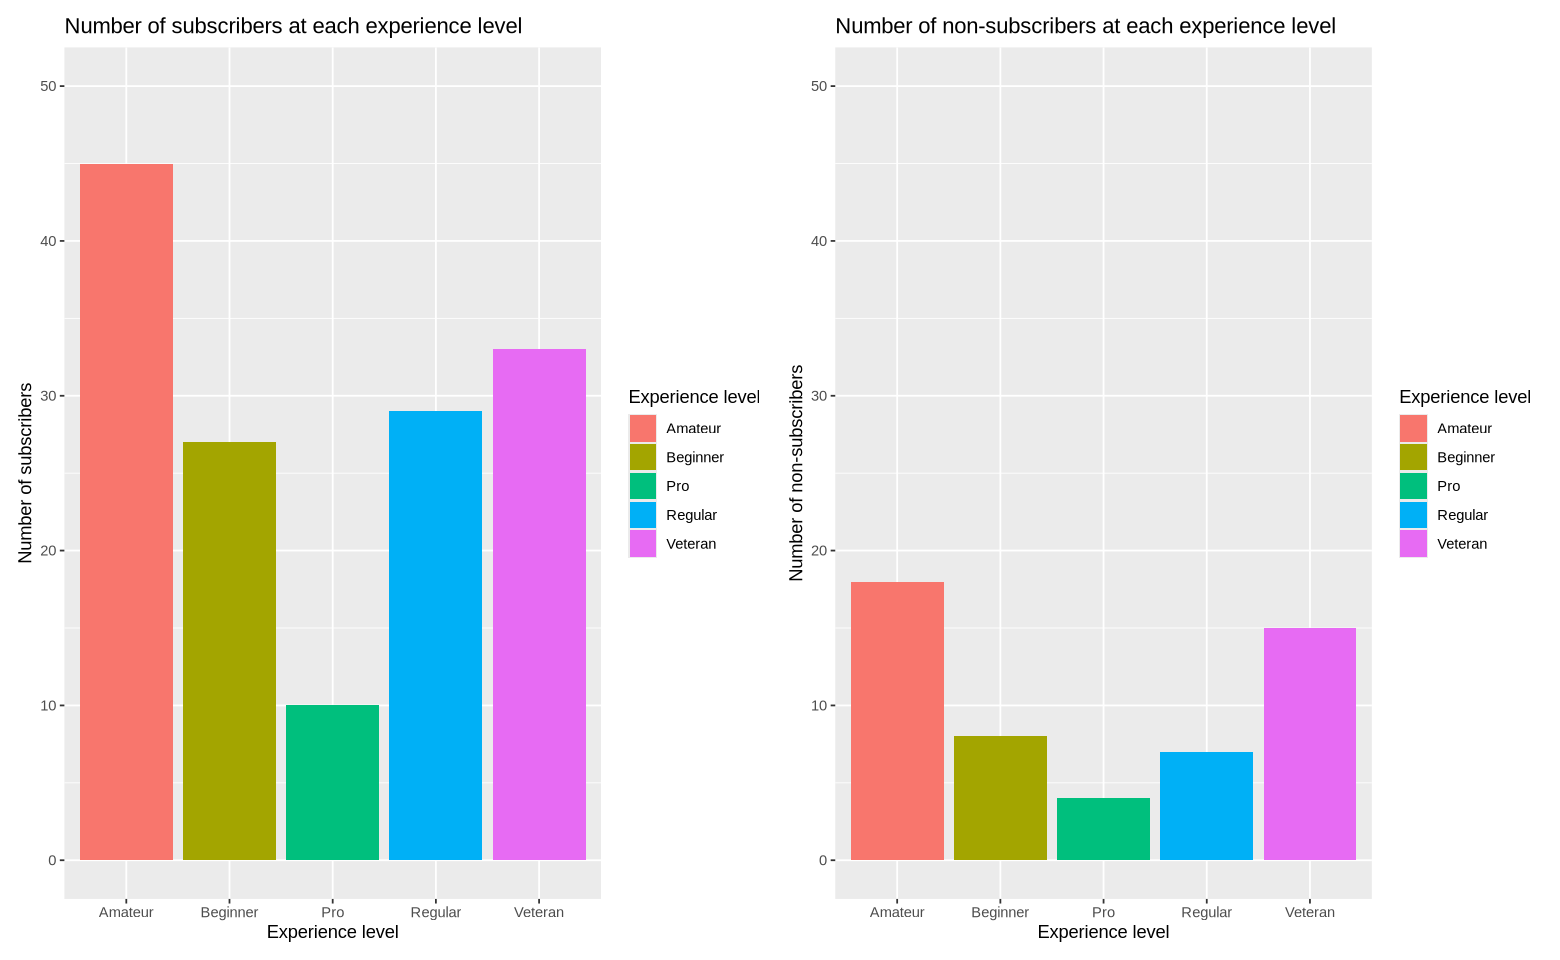

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


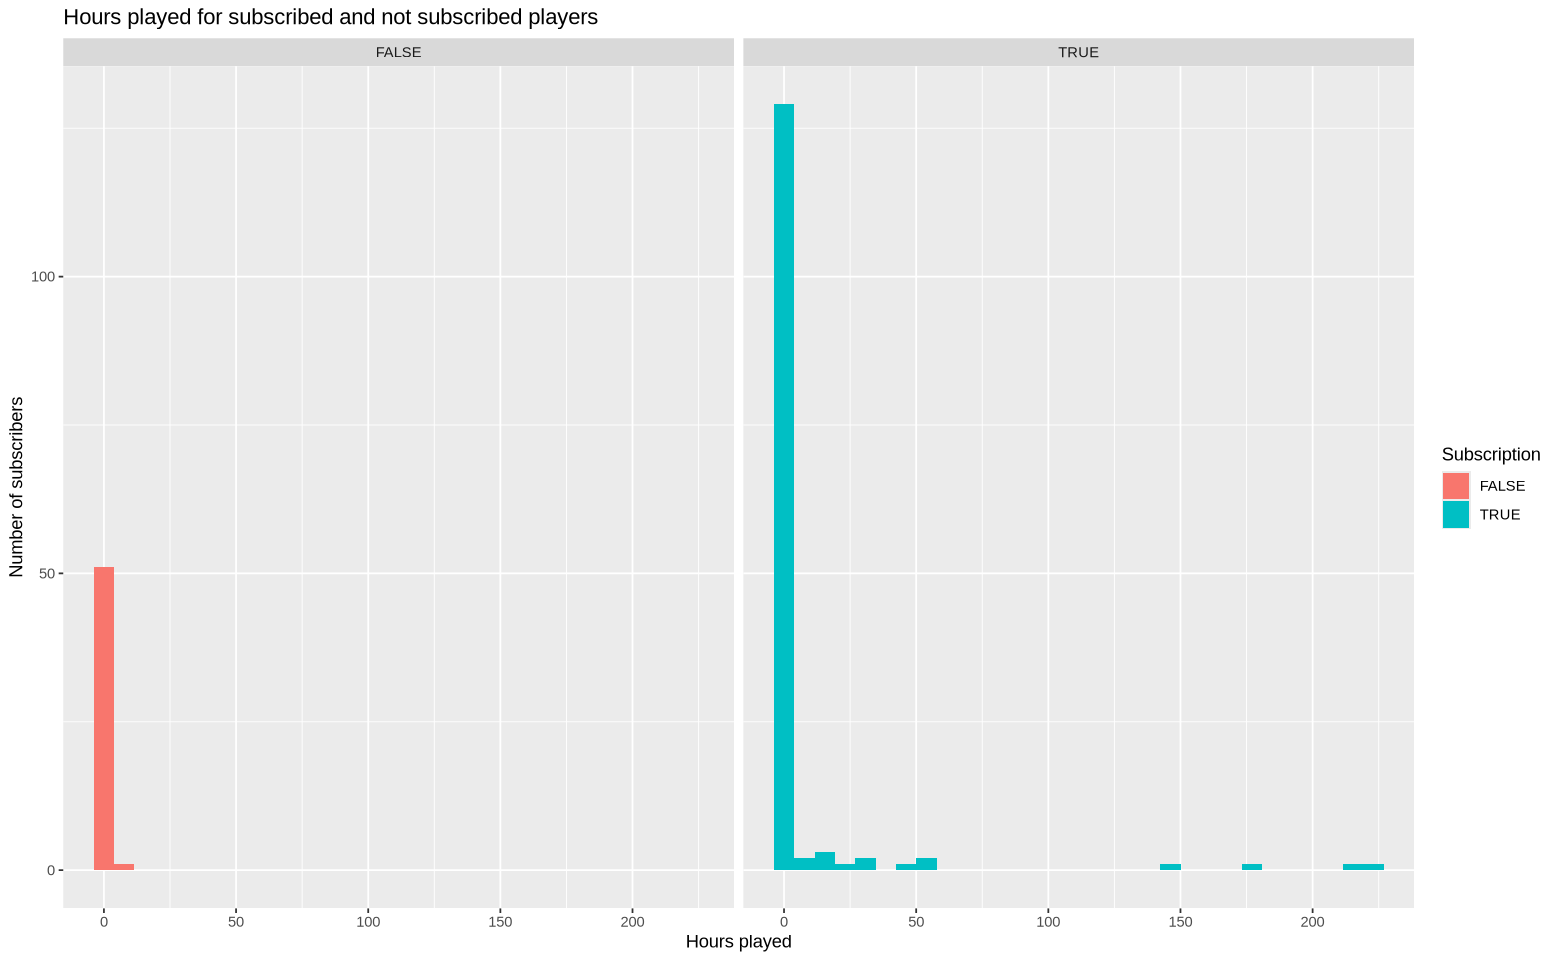

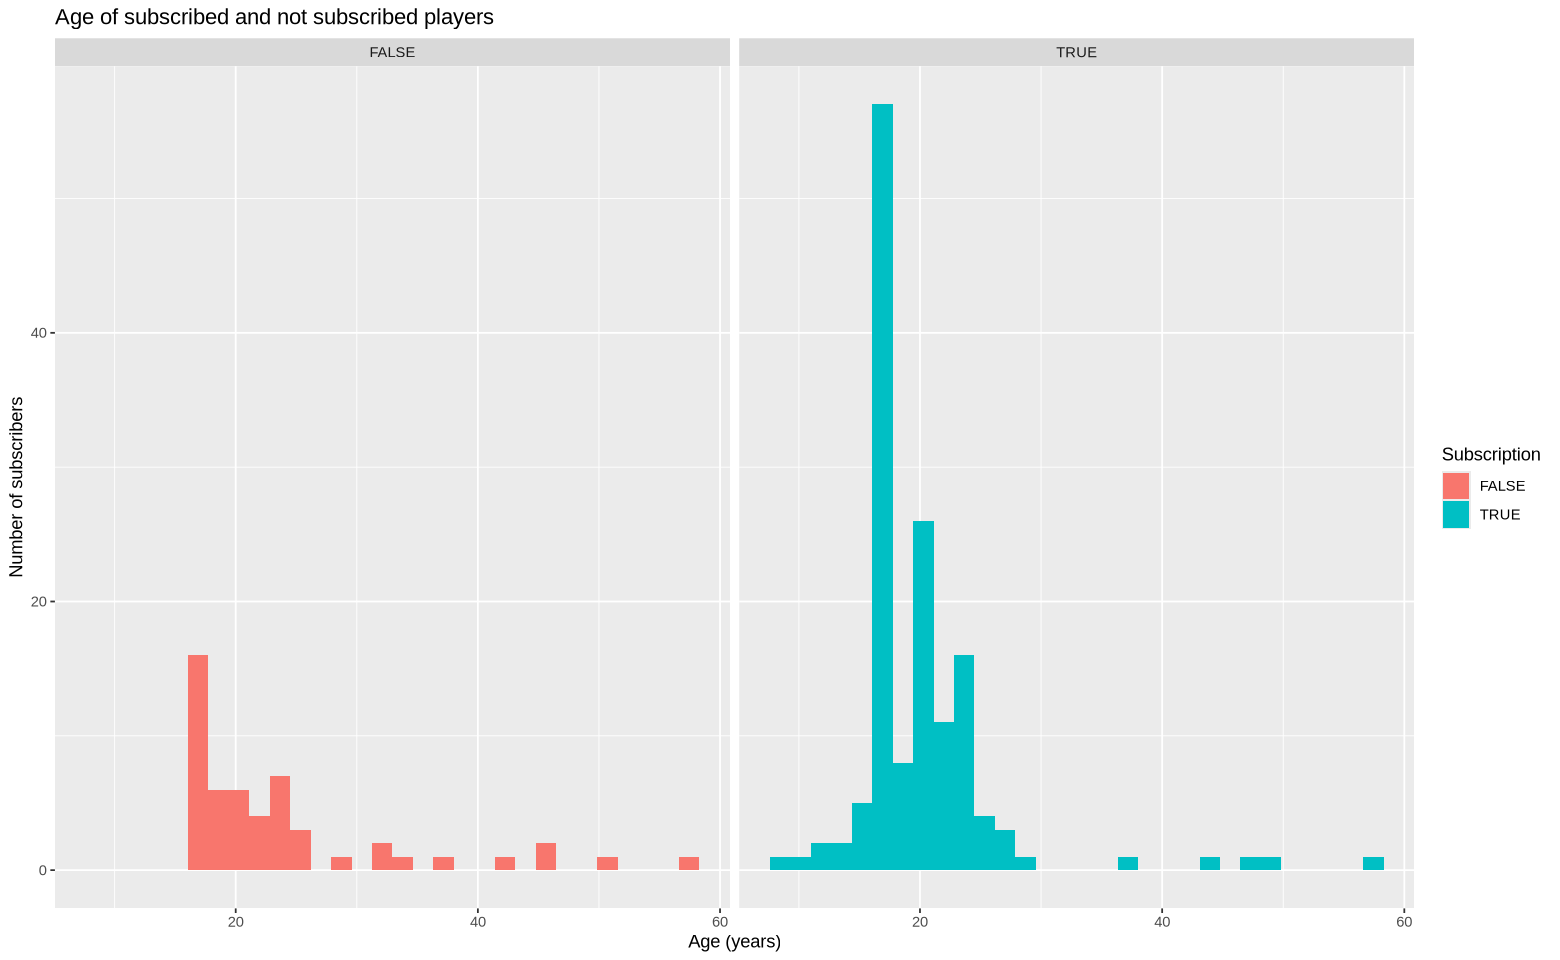

In [30]:
options(repr.plot.width = 13, repr.plot.height = 8)

age_and_hours_plot = tidy_player |>
    ggplot(aes(x = Age, y = played_hours, color = experience)) +
    geom_point() +
    labs(x = 'Age (years)', y = 'Total hours played', color = 'Experience level') +
    ggtitle('Amount of hours played depending on age of participant')

subscribe_and_experience_plot1 = number_of_subscribers |>
    ggplot(aes(x = experience, y = yes_subscribed, fill = experience)) +
    geom_bar(stat = 'identity') +
    ylim(0, 50) +
    labs(x = 'Experience level', y = 'Number of subscribers', fill = 'Experience level') +
    ggtitle('Number of subscribers at each experience level')

subscribe_and_experience_plot2 = number_of_subscribers |>
    ggplot(aes(x = experience, y = no_subscribed, fill = experience)) +
    geom_bar(stat = 'identity') +
    ylim(0, 50) +
    labs(x = 'Experience level', y = 'Number of non-subscribers', fill = 'Experience level') +
    ggtitle('Number of non-subscribers at each experience level')

subscribe_and_experience_plot0 = subscribe_and_experience_plot1 + subscribe_and_experience_plot2

subscribe_vs_hours_played = tidy_player |>
    ggplot(aes(x = played_hours, fill = subscribe)) +
    geom_histogram() +
    facet_grid(cols = vars(subscribe)) +
    labs(x = 'Hours played', y = 'Number of subscribers', fill = 'Subscription') +
    ggtitle('Hours played for subscribed and not subscribed players')

subscribe_vs_age = tidy_player |>
    ggplot(aes(x = Age, fill = subscribe)) +
    geom_histogram() +
    facet_grid(cols = vars(subscribe)) +
    labs(x = 'Age (years)', y = 'Number of subscribers', fill = 'Subscription') +
    ggtitle('Age of subscribed and not subscribed players')
               
age_and_hours_plot
subscribe_and_experience_plot0
subscribe_vs_hours_played
subscribe_vs_age

<h3> Insights </h3>

From the Age vs Subscribed histogram plot it is shown that a majority of the subscriptions are from 15-25 year olds as around three times more people are subscribed while the other ages have around the same amount of subscribed and unsubscribed. In addition, we can see regular experienced people have the highest ratio of subscribed to non-subscribed players. The age and experience level had no observable effect on the amount of hours played and subscribing did not effect the amount of hours played

<h1> The Question </h1>

I will be finding which player characteristics and behabviours are most predictive of subscribing to a game related newletter, and how do these features differ 
between various player types specifcally if the age, experience and played hours of a player can predict if the person will subscribe in the player dataset. The player data set contains the expereience level, age and the amount of hours played as well as the response variable labelled subscribe. Experience and gender are factor vectors so I will convert them into numbers to represent the factor (ex. beginner = 1, amateur = 2, etc.) to use them as predictor variables. I can then isolate these 4 variables, make a model using kknn classification and use a trainng and test set to see if the model is accurate. I will produce plots to visualize the relationship between the predictor variables and the response variableas which can help identify the specefic archetypes of players most likely to subscribe.

<h1> Methods and Plan </h1>

<h3> Why is this method appropiate? </h3>

The k-nearest neighbors (kNN) classification method is appropriate for this analysis because it can model complex, nonlinear relationships between multiple predictors (age, experience, and hours played) and the response variable (subscription status). Since subscription is a logical vector, classification is used instead of linear regression as well as it being suitable for behavioral or demographic data where players with similar profiles are expected to have similar subscription outcomes.

<h3> Assumptions </h3>

1. We need the dataset to be large and diverse enough so that each test instance has similar examples in the training data
2. The training data is large and representative enough of the true population
3. The distance measure meaningfully reflect similarity
4. Converting the factor vectors to numbers will be an accurate representation of their value

<h3> Limitations/Weakness </h3>

1. Limited interpretability of how the variables effect the outcome
2. Must standardize data
3. Sensitive to noise and outliers
4. Can only predict within the range of observed data it was trained on
5. Computationally expensive especially iwth large dataset

<h3> How are you going to compare and select the model? </h3>

I will look at the accuracy, precesion and recall of the model. For this model, we would like a high recall to find people who are likely to subscribe. I will also split the player data set into and use cross-validation to determine the optimal k value.

<h3> How are you going to process the data to apply the model? </h3>

The data will be randomly split the player data in a 75/25 ratio for training and testing set respectively. I will split the data after tidying the data, transforming the factor vectors into dbl and selecting only the variables that will be used. Before applying the kNN algorithm, all continuous predictor variables (age, experience, and hours played) will be standardized to ensure that each contributes equally to the distance metric. I will also perfrom a 5-fold cross-validation on the training set using a 75/25 split to find the most accurate K value. Once it is tuned, it will be evaluated on the test set to how well it can predict subscriptions.